In [1]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')


### Load Dataset, Model, and Scaler


In [2]:
ROOT_DIR = Path.cwd().parent
DATA_DIR = ROOT_DIR / "data" / "NSL-KDD"
MODELS_DIR = ROOT_DIR / "models"
OUTPUT_DIR = ROOT_DIR / "testing_outputs"

MODEL_FILE = MODELS_DIR / "nslkdd_full_rf_model.joblib"
SCALER_FILE = MODELS_DIR / "nslkdd_full_scaler.joblib"
TEST_FILE = DATA_DIR / "KDDTest+.txt"

model = joblib.load(MODEL_FILE)
scaler = joblib.load(SCALER_FILE)
print("Model and Scaler loaded.")


Model and Scaler loaded.


In [3]:
COLUMNS = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files",
    "num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","label","difficulty"
]

test_df = pd.read_csv(TEST_FILE, names=COLUMNS)
y_test = (test_df["label"] != "normal").astype(int)
X_test = test_df.drop(columns=["label", "difficulty"]).copy()

# Apply identical label encoding to match training phase
train_df = pd.read_csv(DATA_DIR / "KDDTrain+.txt", names=COLUMNS)
X_train = train_df.drop(columns=["label", "difficulty"]).copy()

categorical_cols = ["protocol_type", "service", "flag"]
for col in categorical_cols:
    combined = pd.concat([X_train[col], X_test[col]], axis=0).astype(str)
    le = LabelEncoder()
    le.fit(combined)
    X_test[col] = le.transform(X_test[col].astype(str))
    
# Scale features
X_test_scaled = scaler.transform(X_test)
print("Test set preprocessed and scaled.")


Test set preprocessed and scaled.


### Random Forest MDI Feature Importance (Top 15)


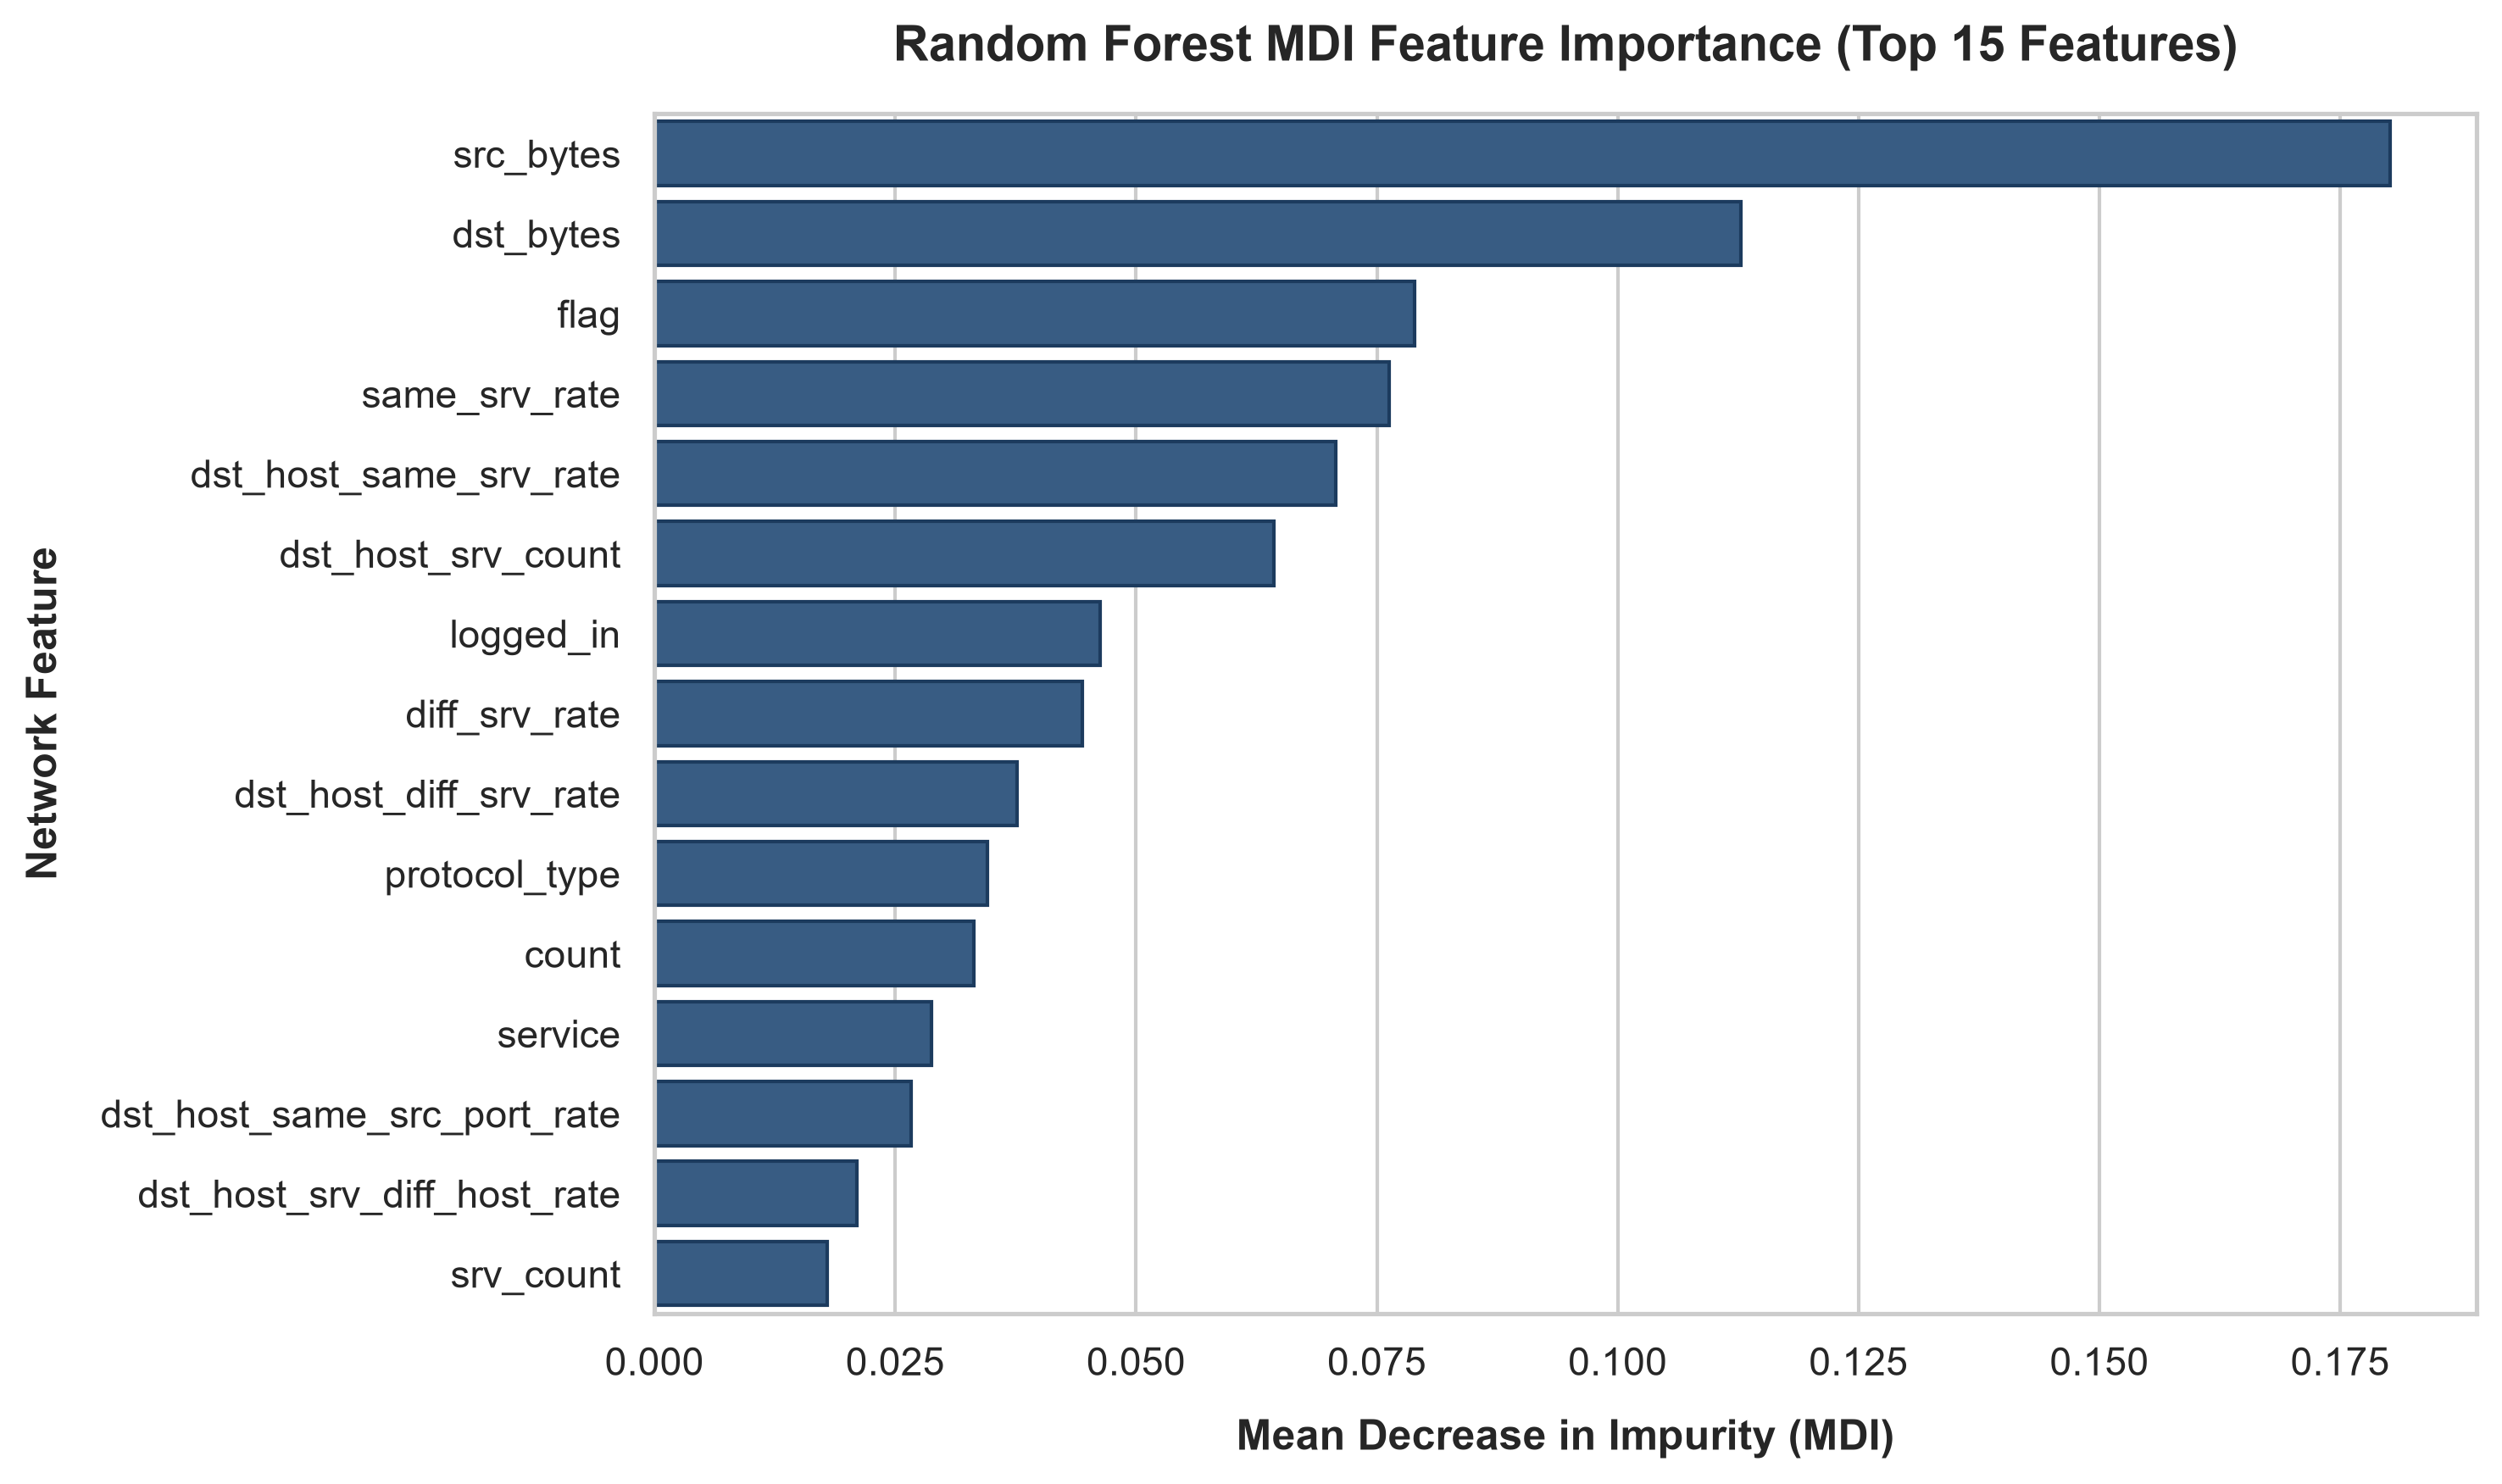

Feature importance chart saved: c:\Users\Mathuravan\Documents\IIT\Final year\FYP\FYP Project\CyberXAI\testing_outputs\rf_feature_importance.png


In [4]:
importances = model.feature_importances_
features = X_test.columns
indices = np.argsort(importances)[::-1]

# Extract top 15 features
top_n = 15
top_indices = indices[:top_n]

plt.figure(figsize=(10, 6), dpi=300)
sns.set_theme(style="whitegrid")
sns.barplot(
    x=importances[top_indices],
    y=features[top_indices],
    color="#2b5c8f",
    edgecolor="#1c3b5e",
    linewidth=1
)

plt.title("Random Forest MDI Feature Importance (Top 15 Features)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Mean Decrease in Impurity (MDI)", fontsize=12, fontweight="bold", labelpad=10)
plt.ylabel("Network Feature", fontsize=12, fontweight="bold", labelpad=10)
plt.tight_layout()

importance_path = OUTPUT_DIR / "rf_feature_importance.png"
plt.savefig(importance_path, bbox_inches="tight")
plt.show()
print(f"Feature importance chart saved: {importance_path}")


### Prediction Probability Distribution Plot
We plot the prediction confidence of the Random Forest model for normal samples versus attack samples. A well-calibrated classifier should group normal sample scores close to `0.0` and attack samples close to `1.0`.


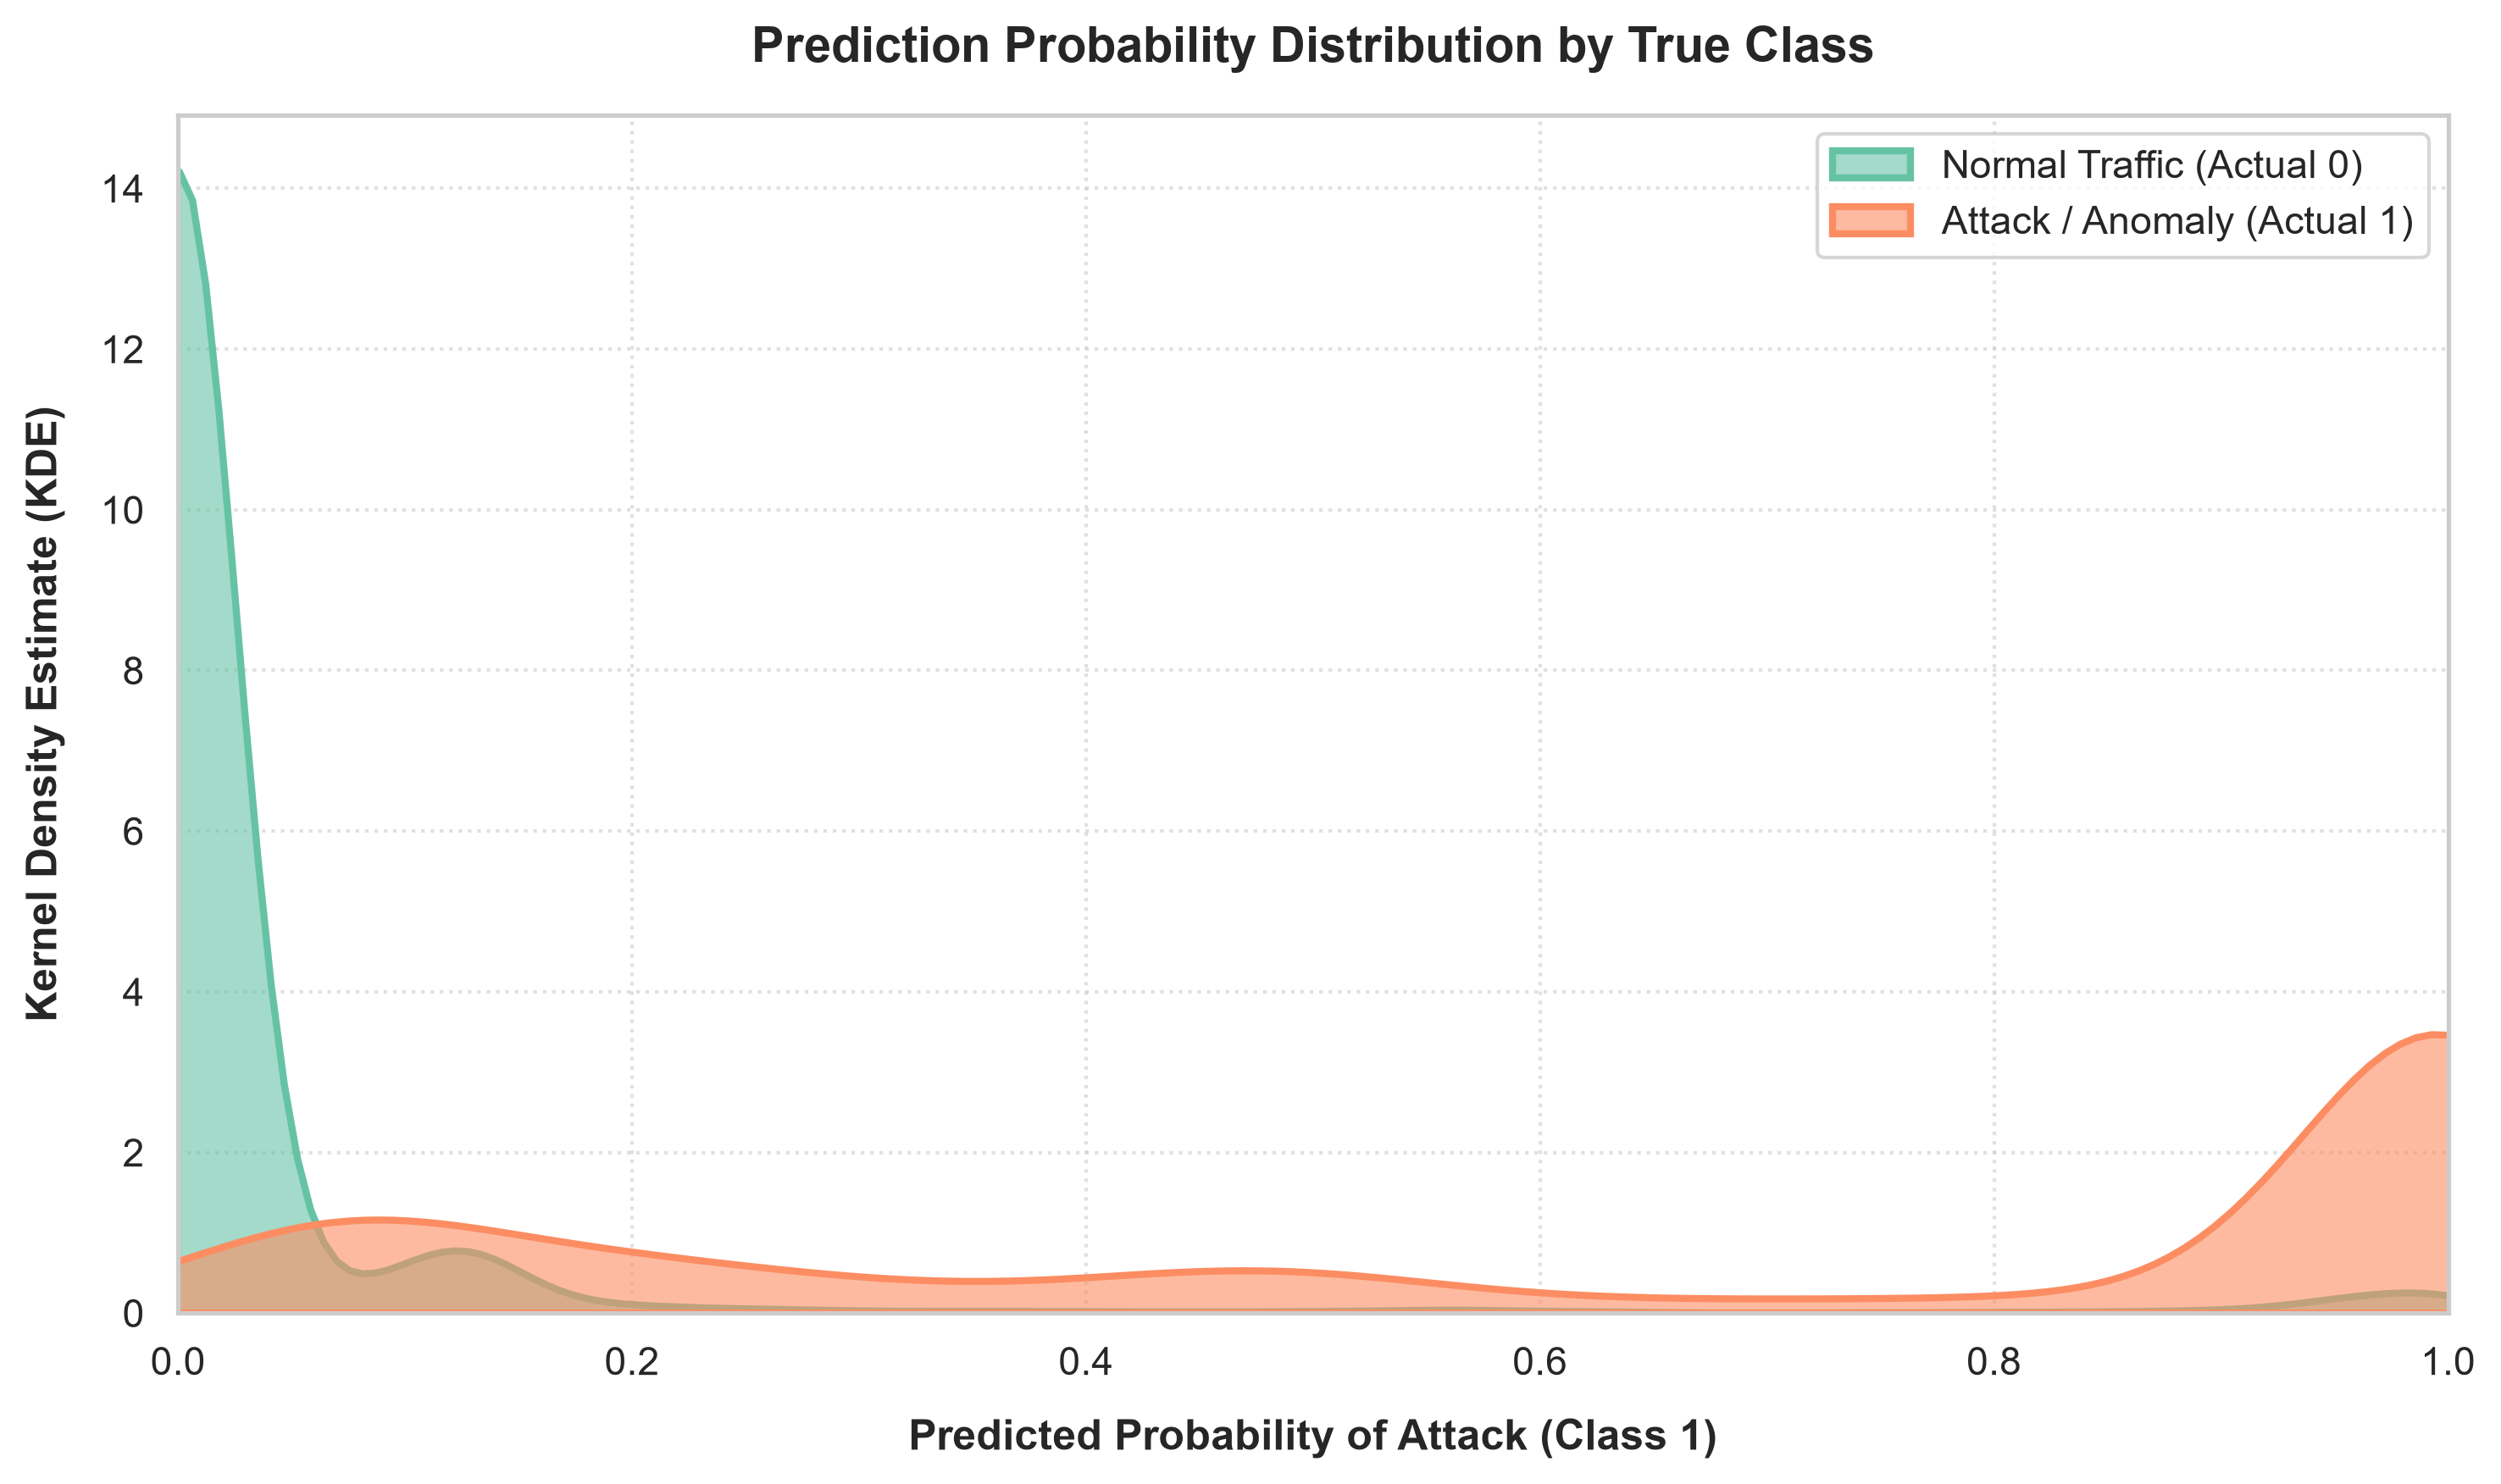

Probability distribution plot saved: c:\Users\Mathuravan\Documents\IIT\Final year\FYP\FYP Project\CyberXAI\testing_outputs\prediction_probability_distribution.png


In [5]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

plt.figure(figsize=(10, 6), dpi=300)
sns.kdeplot(
    y_prob[y_test == 0], 
    fill=True, 
    color="#66c2a5", 
    label="Normal Traffic (Actual 0)", 
    alpha=0.6, 
    linewidth=2
)
sns.kdeplot(
    y_prob[y_test == 1], 
    fill=True, 
    color="#fc8d62", 
    label="Attack / Anomaly (Actual 1)", 
    alpha=0.6, 
    linewidth=2
)

plt.title("Prediction Probability Distribution by True Class", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Predicted Probability of Attack (Class 1)", fontsize=12, fontweight="bold", labelpad=10)
plt.ylabel("Kernel Density Estimate (KDE)", fontsize=12, fontweight="bold", labelpad=10)
plt.xlim(0, 1)
plt.legend(fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

prob_dist_path = OUTPUT_DIR / "prediction_probability_distribution.png"
plt.savefig(prob_dist_path, bbox_inches="tight")
plt.show()
print(f"Probability distribution plot saved: {prob_dist_path}")
